## Model Design and Experiments

This experiment was implemented after studying **GRU, GloVe, and different word embedding techniques**. The goal was to apply the concepts practically and compare different choices based on model performance and overfitting.

### 1. Word Embedding — GloVe

I used **GloVe (Global Vectors for Word Representation)** with **300-dimensional embeddings**.

I chose GloVe because it captures **global statistical information from the corpus**, unlike methods such as **Word2Vec**, which are primarily based on local context.

The GloVe embeddings were used to initialize the Embedding layer instead of starting with randomly initialized embeddings.

The model vocabulary contained **20,000 words**, and the GloVe embeddings achieved **99.51% coverage**:

* Vocabulary size: 20,000
* Embedding dimension: 300
* Words found in GloVe: 19,902
* Coverage: 99.51%

### 2. Why GRU?

I used **GRU (Gated Recurrent Unit)** instead of LSTM.

GRU was selected because it has a **simpler architecture and fewer parameters than LSTM**, which generally makes it faster to train while still being able to capture dependencies in sequential text.

For this sentiment classification task, GRU provides a good balance between **performance, computational cost, and training speed**.

### 3. Bidirectional GRU

I used **Bidirectional GRU** so that the model can process the review in both directions:

* Forward: past → future
* Backward: future → past

This allows the model to use information from both sides of a word when building its representation.

The architecture contains two Bidirectional GRU layers:

* Bidirectional GRU with 128 units
* Bidirectional GRU with 64 units

### 4. Experiment: Trainable GloVe

I first used the pretrained GloVe embeddings with:

```python
trainable=True
```

This allowed the embedding vectors to be fine-tuned during training.

The model achieved high training accuracy, but the training accuracy continued to increase while the validation performance started to decrease. This indicated **overfitting**.

For example, the training accuracy reached approximately **97.5%**, while the validation accuracy remained around **89%**.

### 5. Experiment: Frozen GloVe

I then changed the Embedding layer to:

```python
trainable=False
```

This kept the pretrained GloVe vectors fixed while allowing the GRU and classification layers to learn.

This reduced the degree of overfitting. Although the validation accuracy was slightly lower, the difference was relatively small, and the model showed more stable generalization.

Therefore, I selected:

```python
trainable=False
```

for the final model because it provided a better balance between **performance and overfitting control**.

### 6. Final Model

The final architecture was:

```text
IMDB Reviews
      ↓
Text Preprocessing
      ↓
Tokenization
      ↓
Padding (200 tokens)
      ↓
GloVe 300d Embeddings
      ↓
Spatial Dropout
      ↓
Bidirectional GRU (128)
      ↓
Bidirectional GRU (64)
      ↓
Dense (64, ReLU)
      ↓
Dropout
      ↓
Dense (1, Sigmoid)
      ↓
Positive / Negative
```

### 7. Final Evaluation

The final model achieved approximately:

```text
Test Accuracy: 88.42%
```

The model was also evaluated using:

* Classification Report
* Precision
* Recall
* F1-score
* Confusion Matrix
* Training and Validation Accuracy Curves
* Training and Validation Loss Curves

Overall, this experiment helped demonstrate how the theoretical concepts of **GloVe and GRU** can be combined into a practical NLP sentiment classification system, while also showing the importance of experimenting with pretrained embeddings and controlling overfitting.


In [41]:
import numpy as np 
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub


/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
/kaggle/input/datasets/thanakomsn/glove6b300dtxt/glove.6B.300d.txt


In [42]:
data = pd.read_csv("/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv")

In [43]:
data

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [44]:
data["sentiment"].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

In [45]:
import re

def preprocess_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep apostrophes
    text = re.sub(r"[^a-z0-9'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

data['clean_review'] = data['review'].apply(preprocess_text)

In [46]:
data.head(10)

,review,sentiment,clean_review
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei's love in the time of money is a...
5,"Probably my all-time favorite movie, a story o...",positive,probably my all time favorite movie a story of...
6,I sure would like to see a resurrection of a u...,positive,i sure would like to see a resurrection of a u...
7,"This show was an amazing, fresh & innovative i...",negative,this show was an amazing fresh innovative idea...
8,Encouraged by the positive comments about this...,negative,encouraged by the positive comments about this...
9,If you like original gut wrenching laughter yo...,positive,if you like original gut wrenching laughter yo...


In [47]:
clean_data = data[['clean_review', 'sentiment']]

In [48]:
clean_data.head()

,clean_review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production the filming tech...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,petter mattei's love in the time of money is a...,positive


split before apply tokenization to prevent data leakage 

In [49]:
from sklearn.model_selection import train_test_split

X = clean_data["clean_review"]
y = clean_data["sentiment"].map({
    "negative": 0,
    "positive": 1
})

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=20000,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [51]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [52]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 200

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

In [53]:
print(X_train_pad.shape)
print(X_test_pad.shape)

(40000, 200)
(10000, 200)


In [54]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
/kaggle/input/datasets/thanakomsn/glove6b300dtxt/glove.6B.300d.txt


In [55]:
import numpy as np

GLOVE_PATH = "/kaggle/input/datasets/thanakomsn/glove6b300dtxt/glove.6B.300d.txt"

EMBEDDING_DIM = 300

embeddings_index = {}

with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_index[word] = vector

print("GloVe vocabulary size:", len(embeddings_index))

GloVe vocabulary size: 400000


In [56]:
VOCAB_SIZE = min(20000, len(tokenizer.word_index) + 1)
EMBEDDING_DIM = 300

embedding_matrix = np.zeros(
    (VOCAB_SIZE, EMBEDDING_DIM)
)

words_found = 0

for word, index in tokenizer.word_index.items():

    if index >= VOCAB_SIZE:
        continue

    if word in embeddings_index:
        embedding_matrix[index] = embeddings_index[word]
        words_found += 1

print("VOCAB_SIZE:", VOCAB_SIZE)
print("Words found:", words_found)
print("Embedding matrix shape:", embedding_matrix.shape)

VOCAB_SIZE: 20000
Words found: 19240
Embedding matrix shape: (20000, 300)


In [57]:
from tensorflow.keras.layers import Embedding

embedding_layer = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=300,
    weights=[embedding_matrix],
    trainable=False
)

In [58]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    Bidirectional,
    GRU,
    Dense,
    Dropout,
    SpatialDropout1D
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Bidirectional,
    GRU,
    Dense,
    Dropout,
    SpatialDropout1D
)

model = Sequential([
    
    Input(shape=(MAX_LEN,)),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=300,
        weights=[embedding_matrix],
        trainable=False
    ),

    SpatialDropout1D(0.2),

    Bidirectional(
        GRU(
            128,
            return_sequences=True,
            dropout=0.2
        )
    ),

    Bidirectional(
        GRU(
            64,
            dropout=0.2
        )
    ),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

In [59]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 200, 300)       │     6,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 200, 300)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 200, 256)       │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_7 (Bidirectional) │ (None, 128)            │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,462,209 (24.65 MB)

 Trainable params: 462,209 (1.76 MB)

 Non-trainable params: 6,000,000 (22.89 MB)

In [60]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [61]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=15,
    batch_size=64,
    callbacks=callbacks
)

Epoch 1/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.7276 - loss: 0.5245 - val_accuracy: 0.8273 - val_loss: 0.3774 - learning_rate: 0.0010
Epoch 2/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8372 - loss: 0.3681 - val_accuracy: 0.8627 - val_loss: 0.3119 - learning_rate: 0.0010
Epoch 3/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8565 - loss: 0.3272 - val_accuracy: 0.8709 - val_loss: 0.2914 - learning_rate: 0.0010
Epoch 4/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8731 - loss: 0.2987 - val_accuracy: 0.8817 - val_loss: 0.2885 - learning_rate: 0.0010
Epoch 5/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8824 - loss: 0.2744 - val_accuracy: 0.8831 - val_loss: 0.2848 - learning_rate: 0.0010
Epoch 6/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.8927 - loss: 0.2520 - val_accuracy: 0.8874 - val_loss: 0.2763 - learning_rate: 0.0010
Epoch 7/15
500/500 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - accuracy: 0.9055 - l

In [62]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test
)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8834 - loss: 0.2793
Test Accuracy: 0.883400022983551


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step
Classification Report:

              precision    recall  f1-score   support

    Negative       0.90      0.87      0.88      5000
    Positive       0.87      0.90      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000

Confusion Matrix:
[[4333  667]
 [ 499 4501]]


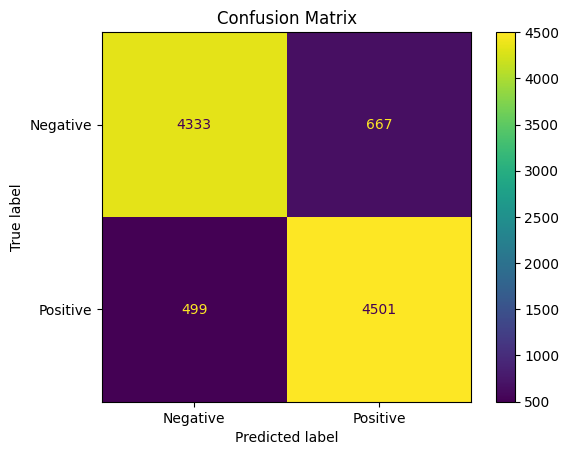

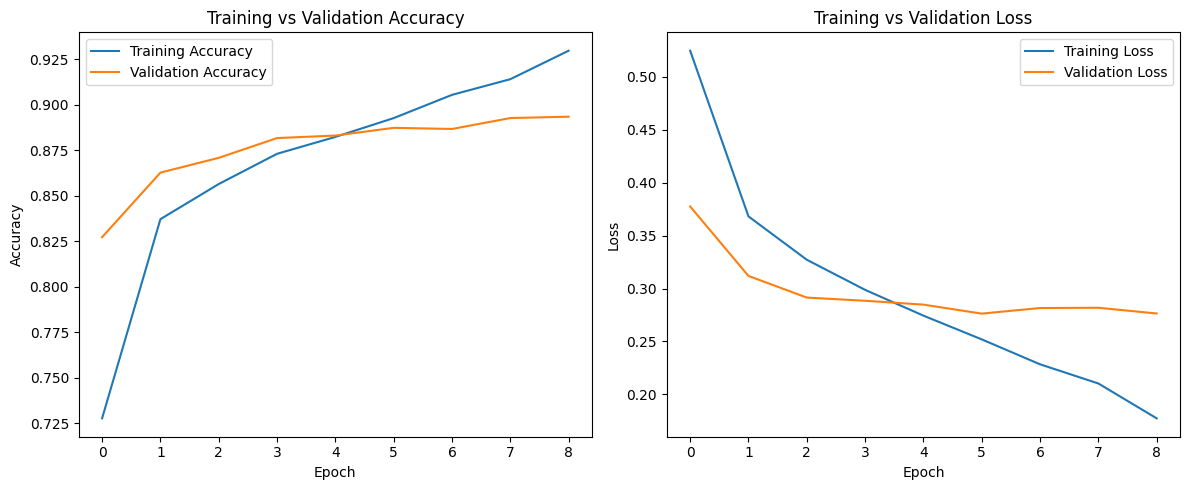

In [63]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================
# 1. Predictions
# =========================

y_pred_prob = model.predict(X_test_pad)

y_pred = (y_pred_prob >= 0.5).astype(int).flatten()


# =========================
# 2. Classification Report
# =========================

print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)


# =========================
# 3. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Negative", "Positive"]
)

disp.plot()

plt.title("Confusion Matrix")
plt.show()


# =========================
# 4. Learning Curves
# =========================

plt.figure(figsize=(12, 5))

# ---- Accuracy ----
plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


# ---- Loss ----
plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [64]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep letters, numbers, and spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def predict_sentiment(review):
    # 1. Preprocessing
    clean_review = preprocess_text(review)

    # 2. Tokenization using the SAME tokenizer
    sequence = tokenizer.texts_to_sequences([clean_review])

    # 3. Padding using the SAME MAX_LEN
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # 4. Prediction
    probability = model.predict(padded, verbose=0)[0][0]

    # 5. Convert probability to sentiment
    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("Review:")
    print(review)

    print("\nCleaned Review:")
    print(clean_review)

    print("\nPrediction:")
    print(sentiment)

    print(f"Positive Probability: {probability:.4f}")
    print(f"Negative Probability: {1 - probability:.4f}")


# Try your own review
my_review = """
This movie was absolutely amazing. The story was interesting,
the acting was excellent, and I really enjoyed every minute of it.
"""

predict_sentiment(my_review)

Review:

This movie was absolutely amazing. The story was interesting,
the acting was excellent, and I really enjoyed every minute of it.


Cleaned Review:
this movie was absolutely amazing the story was interesting the acting was excellent and i really enjoyed every minute of it

Prediction:
Positive
Positive Probability: 0.9950
Negative Probability: 0.0050


In [65]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


def preprocess_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep apostrophes
    text = re.sub(r"[^a-z0-9'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def predict_sentiment(review):
    # 1. Preprocessing
    clean_review = preprocess_text(review)

    # 2. Tokenization using the SAME tokenizer
    sequence = tokenizer.texts_to_sequences([clean_review])

    # 3. Padding using the SAME MAX_LEN
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # 4. Prediction
    probability = model.predict(padded, verbose=0)[0][0]

    # 5. Convert probability to sentiment
    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("Review:")
    print(review)

    print("\nCleaned Review:")
    print(clean_review)

    print("\nPrediction:")
    print(sentiment)

    print(f"Positive Probability: {probability:.4f}")
    print(f"Negative Probability: {1 - probability:.4f}")


# Try your own review
my_review = """
i don't like or hate this movie
"""

predict_sentiment(my_review)

Review:

i don't like or hate this movie


Cleaned Review:
i don't like or hate this movie

Prediction:
Negative
Positive Probability: 0.3550
Negative Probability: 0.6450


In [66]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


def preprocess_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep apostrophes
    text = re.sub(r"[^a-z0-9'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def predict_sentiment(review):
    # 1. Preprocessing
    clean_review = preprocess_text(review)

    # 2. Tokenization using the SAME tokenizer
    sequence = tokenizer.texts_to_sequences([clean_review])

    # 3. Padding using the SAME MAX_LEN
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # 4. Prediction
    probability = model.predict(padded, verbose=0)[0][0]

    # 5. Convert probability to sentiment
    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("Review:")
    print(review)

    print("\nCleaned Review:")
    print(clean_review)

    print("\nPrediction:")
    print(sentiment)

    print(f"Positive Probability: {probability:.4f}")
    print(f"Negative Probability: {1 - probability:.4f}")


# Try your own review
my_review = """
i don't like this movie
"""

predict_sentiment(my_review)

Review:

i don't like this movie


Cleaned Review:
i don't like this movie

Prediction:
Negative
Positive Probability: 0.3400
Negative Probability: 0.6600


In [67]:
import re
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences


def preprocess_text(text):
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep apostrophes
    text = re.sub(r"[^a-z0-9'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


def predict_sentiment(review):
    # 1. Preprocessing
    clean_review = preprocess_text(review)

    # 2. Tokenization using the SAME tokenizer
    sequence = tokenizer.texts_to_sequences([clean_review])

    # 3. Padding using the SAME MAX_LEN
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # 4. Prediction
    probability = model.predict(padded, verbose=0)[0][0]

    # 5. Convert probability to sentiment
    sentiment = "Positive" if probability >= 0.5 else "Negative"

    print("Review:")
    print(review)

    print("\nCleaned Review:")
    print(clean_review)

    print("\nPrediction:")
    print(sentiment)

    print(f"Positive Probability: {probability:.4f}")
    print(f"Negative Probability: {1 - probability:.4f}")


# Try your own review
my_review = """
i don't like this movie ! it's amazing 
"""

predict_sentiment(my_review)

Review:

i don't like this movie ! it's amazing 


Cleaned Review:
i don't like this movie it's amazing

Prediction:
Positive
Positive Probability: 0.9780
Negative Probability: 0.0220
